# 14.4.1 候选字典与顺序阈值回归

## 学习目标与先修知识

从明确的候选项与导数（derivative）构造稀疏方程，公开列尺度、阈值和停止规则。

先修：14.3 字典回归；8.3 最小二乘；2.3 一阶增长。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

种群总量满足增长与拥挤抑制时，候选字典含常数、$x$、$x^2$。只看拟合残差（residual）能否确定哪些项属于生成方程？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先以给定的导数计算三个候选项的数值，避免把字典列当作已证实的机制。

In [2]:
for x in [.2,1.,2.]:print('x=',x,'；[1,x,x²]=',[1,x,x*x],'；导数=',1.2*x-.4*x*x)

x= 0.2 ；[1,x,x²]= [1, 0.2, 0.04000000000000001] ；导数= 0.22399999999999998
x= 1.0 ；[1,x,x²]= [1, 1.0, 1.0] ；导数= 0.7999999999999999
x= 2.0 ；[1,x,x²]= [1, 2.0, 4.0] ；导数= 0.7999999999999998


## 模型假设

教学真值为 $\dot x=1.2x-0.4x^2$，时间单位 T，状态（state）单位 U。此节给出无噪声的导数观测（observation）；参数（parameter）真值只作核验。顺序阈值最小二乘（sequential thresholded least squares，STLSQ）先按训练列二范数（norm）归一化，再对归一化系数用严格给定阈值，活动列重拟合；阈值大于零。

## 数学解释与推导

将 $N$ 个状态对应的候选项排成 $\Theta=[1,x,x^2]$，导数向量（vector） $d$ 满足 $d\approx\Theta\xi$。列尺度 $s_j=\|\Theta_j\|_2$，非零列取 $\tilde\Theta_j=\Theta_j/s_j$；零列尺度约定为1。先最小二乘求 $\tilde\xi$，删去 $|\tilde\xi_j|<\lambda$ 的项，再在保留列上求解，直到支持集合不变或迭代上限。物理系数为 $\xi_j=\tilde\xi_j/s_j$。这是一种稀疏动力学辨识（sparse identification of nonlinear dynamics，SINDy）计算步骤；共线候选、缺乏激励或导数误差会令方程结构不唯一。

## 核心实现

以下是本节完整计算步骤，可逐行修改。

In [3]:
def sparse_stlsq(theta, derivative, threshold, max_iter):
    """Column-normalized sequential thresholded least squares."""
    library = np.asarray(theta, dtype=float)
    target = np.asarray(derivative, dtype=float)
    scales = np.linalg.norm(library, axis=0)
    safe = np.where(scales > 0, scales, 1.)
    normalized = library / safe
    coefficient = np.linalg.lstsq(normalized, target, rcond=None)[0]
    support = np.abs(coefficient) >= threshold
    for _ in range(max_iter):
        if not np.any(support):
            coefficient[:] = 0
            break
        updated = np.zeros_like(coefficient)
        updated[support] = np.linalg.lstsq(normalized[:, support], target, rcond=None)[0]
        new_support = np.abs(updated) >= threshold
        coefficient = updated
        if np.array_equal(new_support, support):
            break
        support = new_support
    support = np.abs(coefficient) >= threshold
    coefficient[~support] = 0
    return [(coefficient / safe).tolist(), np.flatnonzero(support).tolist()]


def logistic_exact(times, initial, growth, crowding):
    """Exact logistic trajectory for growth>0 and positive initial state."""
    clock = np.asarray(times, dtype=float)
    exponential = np.exp(growth * clock)
    return growth * initial * exponential / (growth + crowding * initial * (exponential-1))

## 对照实验

在宽范围、无噪声的状态上拟合已知两项方程，并改变阈值观察活动项。

阈值 0.01 活动项 [1, 2] 系数 [ 0.   1.2 -0.4]
阈值 0.2 活动项 [1, 2] 系数 [ 0.   1.2 -0.4]
阈值 1.0 活动项 [1, 2] 系数 [ 0.   1.2 -0.4]
阈值 3.0 活动项 [1, 2] 系数 [ 0.   1.2 -0.4]


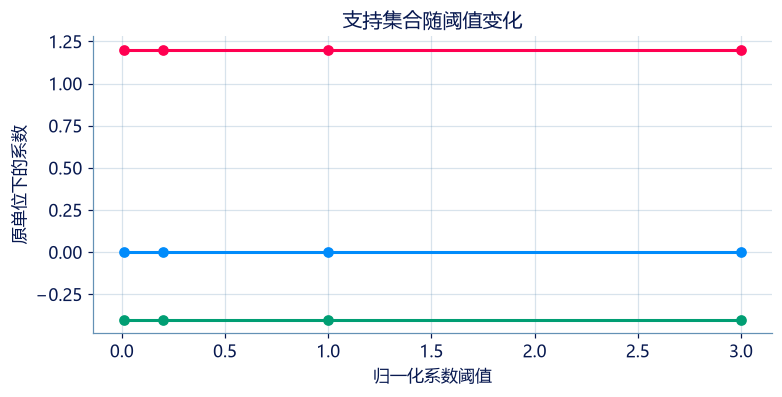

In [4]:
x=np.linspace(.1,2.5,50);theta=np.column_stack([np.ones_like(x),x,x*x]);derivative=1.2*x-.4*x*x
levels=[.01,.2,1.,3.];rows=[]
for threshold in levels:
    coefficients,active=sparse_stlsq(theta,derivative,threshold,8)
    rows.append(coefficients);print('阈值',threshold,'活动项',active,'系数',np.round(coefficients,4))
fig,ax=plt.subplots(figsize=(7,3.5));ax.plot(levels,rows,'o-');ax.set(xlabel='归一化系数阈值',ylabel='原单位下的系数',title='支持集合随阈值变化');ax.grid(alpha=.25);plt.show()

## 结果解释

低阈值下可恢复已知两项，但这依赖候选项、状态覆盖和导数质量。阈值过高会删除真实项；还要用新初态的预测检查筛选出的方程。

### 独立核对

用已知无噪声系数独立核对；测试空支持和零候选列。

In [5]:
coefficient,active=sparse_stlsq(theta,derivative,.01,8)
np.testing.assert_allclose(coefficient,[0,1.2,-.4],atol=1e-10);assert active==[1,2]
blank,none=sparse_stlsq(theta,derivative,1e6,8);assert none==[] and np.allclose(blank,0)
zero,_=sparse_stlsq([[1.,0.],[2.,0.]],[2.,4.],.01,8);assert zero[1]==0
print('已知系数、空支持与零列核验通过。')

已知系数、空支持与零列核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/14-04-%E7%A8%80%E7%96%8F%E5%8A%A8%E5%8A%9B%E5%AD%A6%E8%BE%A8%E8%AF%86/explore/)，再返回此处核对完整推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：按列归一化的稀疏辨识

给定候选字典 theta 与导数（derivative）观测（observation），按题定顺序阈值最小二乘（sequential thresholded least squares，STLSQ）返回原单位系数及活动列索引。

**函数与代码模板**

```python
def solve(
    theta: list[list[float]],
    derivative: list[float],
    threshold: float,
    max_iter: int,
) -> tuple[list[float], list[int]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `theta` | `list[list[float]]` | N×p 候选项设计矩阵（design matrix）。 | 按列定义 |
| `derivative` | `list[float]` | N 个导数观测。 | U/T |
| `threshold` | `float` | 归一化系数的正阈值。 | U/T |
| `max_iter` | `int` | 最多重新拟合次数，允许0。 | 次 |

**返回值**

按以下顺序返回元组：(coefficients, active)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `coefficients` | `list[float]` | 按原候选列顺序的物理系数。 | 按列定义 |
| `active` | `list[int]` | 非零活动列的从0开始索引。 | 个 |

**计算规则**

列二范数（norm）归一化；零列尺度设1。先全列最小二乘，取绝对系数≥threshold 的支持，再最多 max_iter 次仅在支持上拟合并重定支持；支持不变即停止。最后低于阈值的系数置0，并除以列尺度。最小二乘使用 numpy.linalg.lstsq 的默认秩（rank）判定。

**约束与边界**

- N,p≥1，threshold>0，max_iter≥0；全部输入（input）有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| theta | N×p 候选项设计矩阵（design matrix）。 | [[1.0, 0.0], [0.0, 1.0]] | 按列定义 |
| derivative | N 个导数观测。 | [0.0, 2.0] | U/T |
| threshold | 归一化系数的正阈值。 | 0.1 | U/T |
| max_iter | 最多重新拟合次数，允许0。 | 5 | 次 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
theta = [[1.0, 0.0], [0.0, 1.0]]
derivative = [0.0, 2.0]
threshold = 0.1
max_iter = 5

result = solve(theta, derivative, threshold, max_iter)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| coefficients | 按原候选列顺序的物理系数。 | [0.0, 2.0] | 按列定义 |
| active | 非零活动列的从0开始索引。 | [1] | 个 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.0, 2.0], [1])
```

**样例解释**

首例只有第二列活动，系数为 [0,2]；阈值和列尺度是答案的一部分。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：按列归一化的稀疏辨识](http://127.0.0.1:8000/chapters/14-04-%E7%A8%80%E7%96%8F%E5%8A%A8%E5%8A%9B%E5%AD%A6%E8%BE%A8%E8%AF%86/practice/?question=p14-sparse-stlsq)

### 第 2 题 · 单项选择题：为何声明列尺度

候选列 x 与 x² 的数值范围不同，为什么阈值前需要明确列尺度？

- **A.** 同一数值阈值会随列缩放改变支持，需说明归一化与还原。
- **B.** 因为列尺度能证明因果方向。
- **C.** 因为所有多项式列都同单位。
- **D.** 因为归一化后可不再还原物理系数。

[作答：为何声明列尺度](http://127.0.0.1:8000/chapters/14-04-%E7%A8%80%E7%96%8F%E5%8A%A8%E5%8A%9B%E5%AD%A6%E8%BE%A8%E8%AF%86/practice/?question=p14-column-scale)

### 第 3 题 · 单项选择题：共线候选的边界

在训练状态（state）中 x² 与 x 几乎共线，两个稀疏方程都拟合得好。哪项判断合理？

- **A.** 当前数据不足以稳定区分两项，应增加有区分力的状态范围。
- **B.** 较短方程必是真实机制。
- **C.** 训练误差相同就说明模型（model）物理完全相同。
- **D.** 只改图表颜色可解决。

[作答：共线候选的边界](http://127.0.0.1:8000/chapters/14-04-%E7%A8%80%E7%96%8F%E5%8A%A8%E5%8A%9B%E5%AD%A6%E8%BE%A8%E8%AF%86/practice/?question=p14-collinear-terms)

### 第 4 题 · 单项选择题：候选项与机制

字典中出现 x² 且其拟合系数非零，意味着什么？

- **A.** 它是在当前字典和数据下保留的候选项，仍需独立检验。
- **B.** 已经证明生物体真实具有该机制。
- **C.** 其他遗漏变量不可能存在。
- **D.** 模型（model）必能预测任何初值（initial condition）。

[作答：候选项与机制](http://127.0.0.1:8000/chapters/14-04-%E7%A8%80%E7%96%8F%E5%8A%A8%E5%8A%9B%E5%AD%A6%E8%BE%A8%E8%AF%86/practice/?question=p14-candidate-mechanism)

**进一步阅读**

[Brunton、Proctor 与 Kutz 的 SINDy 原论文](https://doi.org/10.1073/pnas.1517384113)提出稀疏动力学辨识；本节是课程构造，不声称论文复现。